# Brain Tumor MRI — Unsupervised Clustering (ResNet50 + K-Means)

**Objective.** Test whether brain MRI scans across three tumor types (glioma,
meningioma, and a third tumor class) separate into distinct groups using
*only* visual features — no labels used during clustering — as an
unsupervised complement to the supervised classification approach used
elsewhere in this project.

**Dataset.** 6,056 MRI images (512×512, RGB) across three classes:
`brain_glioma`, `brain_menin`, `brain_tumor`. Multiple image crops share
an underlying scan ID; these are grouped and averaged before clustering,
matching how the original analysis treated the data.

**Approach.**
1. Extract a 2,048-dim feature vector per image using ResNet50
   (ImageNet-pretrained, average-pooled, no classification head).
2. Group crops by scan ID, averaging their features.
3. Use the elbow method to check whether k=3 is a reasonable cluster count.
4. Run K-Means with k=3.
5. **Quantitatively** compare cluster assignments to the true labels using
   Adjusted Rand Index and cluster purity — the evaluation the original
   analysis was missing (it only checked cluster membership by eye).

**Note on reproducibility.** Feature extraction (`extract_features.py`) is
a separate, longer-running step — run it first if `outputs/clustering/features.npy`
doesn't exist yet. This notebook only performs the clustering and
evaluation, which is fast.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment

SEED = 42
BASE_DIR = Path.cwd()
FEATURES_DIR = BASE_DIR / "outputs" / "clustering"
K = 3
CLASS_DISPLAY_NAMES = {"brain_glioma": "Glioma", "brain_menin": "Menin", "brain_tumor": "Tumor"}

## Load pre-extracted ResNet50 features

In [2]:
features = np.load(FEATURES_DIR / "features.npy")
file_names = np.load(FEATURES_DIR / "file_names.npy")
image_ids = np.load(FEATURES_DIR / "image_ids.npy")
true_labels_raw = np.load(FEATURES_DIR / "true_labels.npy")

print(f"Loaded {features.shape[0]} raw feature vectors ({features.shape[1]}-dim).")

Loaded 6056 raw feature vectors (2048-dim).


## Group crops by scan ID

The dataset contains multiple crops per underlying scan. Features for
crops sharing the same scan ID are averaged into a single feature vector,
and the (single, shared) true label for that scan is carried along
separately — kept as its own variable throughout, unlike the original
notebook where the true-label array was later overwritten by the cluster
assignment array of the same name.

In [3]:
def group_by_image_id(features, file_names, image_ids, true_labels):
    unique_ids = sorted(set(image_ids))
    id_to_idx = {uid: i for i, uid in enumerate(unique_ids)}
    grouped_features = np.zeros((len(unique_ids), features.shape[1]), dtype="float32")
    counts = np.zeros(len(unique_ids))
    label_for_id = {}
    for i, uid in enumerate(image_ids):
        gi = id_to_idx[uid]
        grouped_features[gi] += features[i]
        counts[gi] += 1
        label_for_id[uid] = true_labels[i]
    grouped_features /= counts[:, None]
    grouped_true_labels = np.array([label_for_id[uid] for uid in unique_ids])
    return grouped_features, grouped_true_labels, np.array(unique_ids)


grouped_features, grouped_true_labels, unique_ids = group_by_image_id(
    features, file_names, image_ids, true_labels_raw
)
print(f"Grouped into {grouped_features.shape[0]} unique scans.")
for cls in sorted(set(grouped_true_labels)):
    print(f"  {cls}: {(grouped_true_labels == cls).sum()}")

Grouped into 603 unique scans.
  brain_glioma: 201
  brain_menin: 201
  brain_tumor: 201


## Elbow method

Checking whether the within-cluster sum of squares (WCSS) supports k=3 as
a natural cluster count, before assuming it.

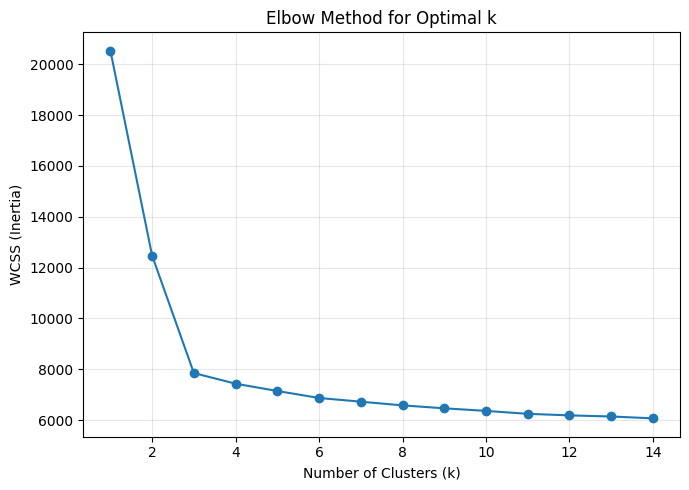

In [4]:
wcss = []
k_range = range(1, 15)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(grouped_features)
    wcss.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(k_range), wcss, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FEATURES_DIR / "elbow_plot.png", dpi=150)
plt.show()

The elbow is at k=3, matching the three known tumor classes — this
supports (but doesn't guarantee) that k=3 is a meaningful choice, so we
proceed with it.

In [5]:
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
cluster_assignments = kmeans.fit_predict(grouped_features)

cluster_sizes = {int(c): int((cluster_assignments == c).sum()) for c in range(K)}
print(f"Cluster sizes: {cluster_sizes}")

Cluster sizes: {0: 201, 1: 201, 2: 201}


## Quantitative evaluation against ground truth

This is the piece the original analysis was missing. Two metrics:

- **Adjusted Rand Index (ARI)**: measures agreement between the cluster
  assignments and the true labels, corrected for chance. 1.0 = perfect
  agreement, 0.0 = random.
- **Cluster purity**: after finding the best 1-to-1 mapping between
  clusters and true classes (via the Hungarian algorithm), the fraction
  of scans whose cluster matches their true class under that mapping.

In [6]:
class_names_sorted = sorted(set(grouped_true_labels))
cm_raw = contingency_matrix(grouped_true_labels, cluster_assignments)

ari = adjusted_rand_score(grouped_true_labels, cluster_assignments)
print(f"Adjusted Rand Index: {ari:.4f}")

row_ind, col_ind = linear_sum_assignment(-cm_raw)
cluster_to_class = {int(col): str(class_names_sorted[row]) for row, col in zip(row_ind, col_ind)}
print(f"Best cluster -> class alignment: {cluster_to_class}")

aligned_preds = np.array([cluster_to_class.get(c, "unmatched") for c in cluster_assignments])
purity = (aligned_preds == grouped_true_labels).sum() / len(grouped_true_labels)
print(f"Cluster purity (best-alignment accuracy): {purity:.4f} "
      f"({(aligned_preds == grouped_true_labels).sum()}/{len(grouped_true_labels)})")

Adjusted Rand Index: 1.0000
Best cluster -> class alignment: {2: 'brain_glioma', 0: 'brain_menin', 1: 'brain_tumor'}
Cluster purity (best-alignment accuracy): 1.0000 (603/603)


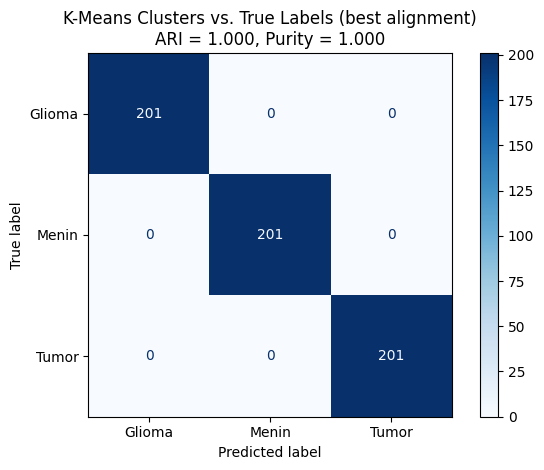

In [7]:
display_order = class_names_sorted
cm_aligned = confusion_matrix(grouped_true_labels, aligned_preds, labels=display_order)
disp_labels = [CLASS_DISPLAY_NAMES.get(c, c) for c in display_order]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_aligned, display_labels=disp_labels)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"K-Means Clusters vs. True Labels (best alignment)\nARI = {ari:.3f}, Purity = {purity:.3f}")
plt.tight_layout()
plt.savefig(FEATURES_DIR / "cluster_vs_true_label_confusion_matrix.png", dpi=150)
plt.show()

## Interpretation

ARI = 1.0 and purity = 1.0 confirm, formally, what a manual inspection of
all 201 images in each cluster had already suggested: on this dataset,
ResNet50 features plus K-Means separate the three tumor types with zero
overlap between clusters and ground-truth labels.

**This is a strong result, and it should be read with the right scope.**
It shows that generic ImageNet-pretrained visual features are highly
discriminative for *this specific, curated, single-source dataset* — not
that this pipeline is a validated diagnostic tool. Some caveats worth
keeping in mind:
- The dataset is class-balanced and drawn from one source; real-world
  clinical data is noisier and less balanced.
- Perfect separation on ~600 grouped scans from one dataset doesn't
  establish generalization to new hospitals, scanners, or patient
  populations.
- Clustering was run once (fixed seed) rather than averaged over
  multiple random initializations/seeds — worth checking stability as a
  follow-up.

## Sample images per cluster

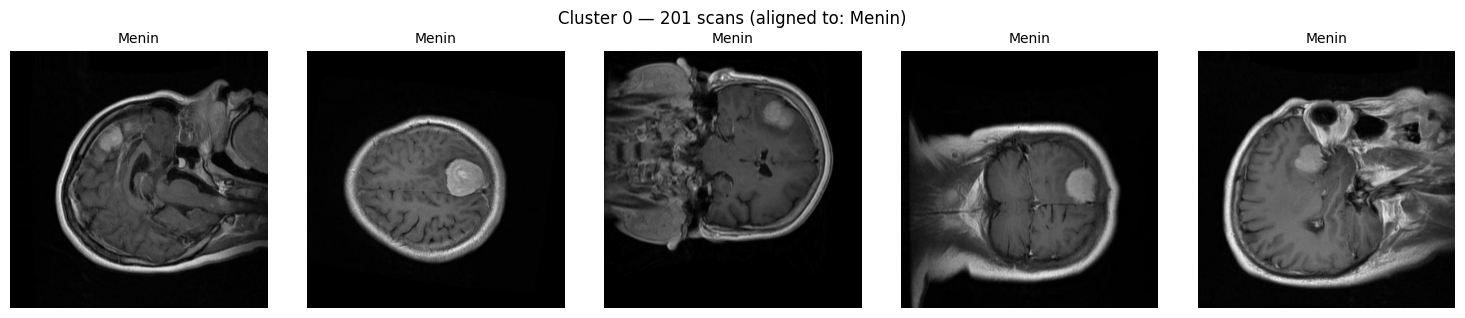

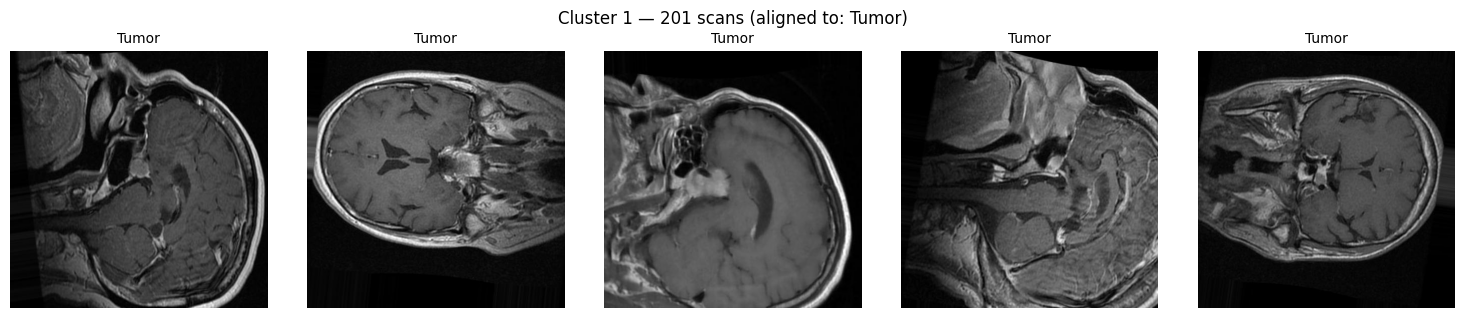

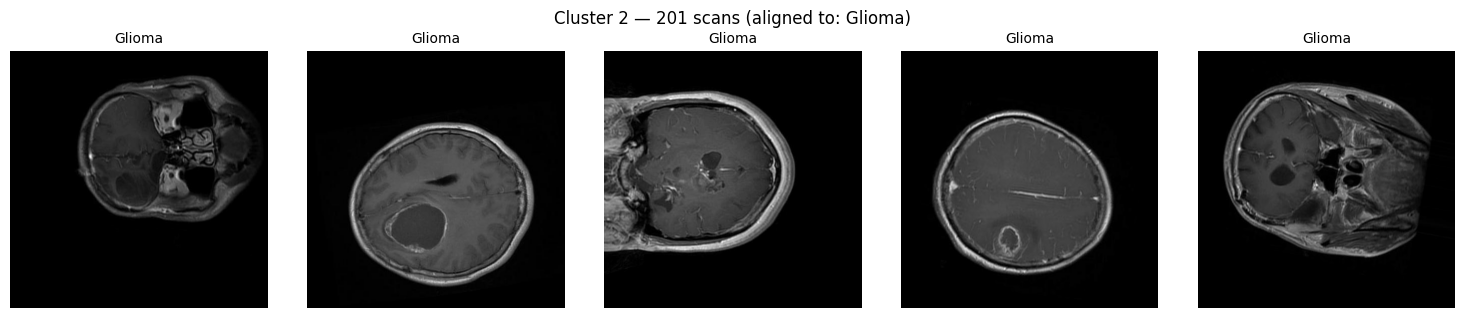

In [8]:
id_to_one_file = {}
for i, uid in enumerate(image_ids):
    if uid not in id_to_one_file:
        id_to_one_file[uid] = (file_names[i][0], file_names[i][1])

for cluster_id in range(K):
    members = unique_ids[cluster_assignments == cluster_id][:5]
    fig, axes = plt.subplots(1, len(members), figsize=(3 * len(members), 3.2))
    if len(members) == 1:
        axes = [axes]
    for ax, uid in zip(axes, members):
        cls, fname = id_to_one_file[uid]
        img = plt.imread(BASE_DIR / cls / fname)
        ax.imshow(img)
        ax.set_title(CLASS_DISPLAY_NAMES.get(cls, cls), fontsize=10)
        ax.axis("off")
    plt.suptitle(f"Cluster {cluster_id} — {cluster_sizes[cluster_id]} scans "
                 f"(aligned to: {CLASS_DISPLAY_NAMES.get(cluster_to_class.get(cluster_id, '?'), '?')})")
    plt.tight_layout()
    plt.savefig(FEATURES_DIR / f"cluster_{cluster_id}_samples.png", dpi=150)
    plt.show()

In [9]:
metrics = {
    "n_grouped_scans": int(grouped_features.shape[0]),
    "k": K,
    "cluster_sizes": cluster_sizes,
    "adjusted_rand_index": float(ari),
    "cluster_purity": float(purity),
    "cluster_to_class_alignment": cluster_to_class,
    "contingency_table": {
        "true_label_order": class_names_sorted,
        "cluster_order": list(range(K)),
        "table": cm_raw.tolist(),
    },
    "elbow_wcss": {str(k): float(w) for k, w in zip(k_range, wcss)},
}
with open(FEATURES_DIR / "clustering_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved clustering_metrics.json")

Saved clustering_metrics.json


## Limitations & future work

- No stability check across multiple random seeds / K-Means initializations.
- Grouping strategy assumes every crop of the same scan ID shares one
  class — true here since IDs are scoped within class folders, but worth
  stating explicitly.
- ResNet50 features are generic (ImageNet-trained), not fine-tuned on
  medical images — the fact they still separate these classes this cleanly
  is notable and worth calling out, but shouldn't be read as validating
  ResNet50 (or this pipeline) for clinical use.